In [ ]:
import pandas as pd

matches_path = "dataFiles/matches.csv"
deliveries_path = "dataFiles/deliveries.csv"

matches = pd.read_csv(matches_path)
deliveries = pd.read_csv(deliveries_path)

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)



Matches shape: (1243, 11)
Deliveries shape: (295732, 20)


/tmp/ipykernel_681/606952774.py:7: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  deliveries = pd.read_csv(deliveries_path)


# Data Cleaning Steps:

In [ ]:
print("MATCHES")
print(matches.shape)
display(matches.head())
print(matches.info())

print("\nDELIVERIES")
print(deliveries.shape)
display(deliveries.head())
print(deliveries.info())

MATCHES
(1243, 11)


,match_id,season,date,team1,team2,winner,result,venue,city,toss_winner,toss_decision
0,1082591,2017,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,NaN,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Royal Challengers Bangalore,field
1,1082592,2017,2017-04-06,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,NaN,Maharashtra Cricket Association Stadium,Pune,Rising Pune Supergiant,field
2,1082593,2017,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,NaN,Saurashtra Cricket Association Stadium,Rajkot,Kolkata Knight Riders,field
3,1082594,2017,2017-04-08,Kings XI Punjab,Rising Pune Supergiant,Kings XI Punjab,NaN,Holkar Cricket Stadium,Indore,Kings XI Punjab,field
4,1082595,2017,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,NaN,M.Chinnaswamy Stadium,Bengaluru,Royal Challengers Bangalore,bat


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   match_id       1243 non-null   int64 
 1   season         1243 non-null   object
 2   date           1243 non-null   object
 3   team1          1243 non-null   object
 4   team2          1243 non-null   object
 5   winner         1218 non-null   object
 6   result         25 non-null     object
 7   venue          1243 non-null   object
 8   city           1192 non-null   object
 9   toss_winner    1243 non-null   object
 10  toss_decision  1243 non-null   object
dtypes: int64(1), object(10)
memory usage: 106.9+ KB
None

DELIVERIES
(295732, 20)


,match_id,season,date,innings,batting_team,over,delivery,batter,bowler,batter_runs,extras_runs,total_runs,wides,noballs,byes,legbyes,penalty,wicket,wicket_kind,player_out
0,1082591,2017,2017-04-05,1,Sunrisers Hyderabad,0,1,DA Warner,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN
1,1082591,2017,2017-04-05,1,Sunrisers Hyderabad,0,2,DA Warner,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN
2,1082591,2017,2017-04-05,1,Sunrisers Hyderabad,0,3,DA Warner,TS Mills,4,0,4,0,0,0,0,0,0,NaN,NaN
3,1082591,2017,2017-04-05,1,Sunrisers Hyderabad,0,4,DA Warner,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN
4,1082591,2017,2017-04-05,1,Sunrisers Hyderabad,0,5,DA Warner,TS Mills,0,2,2,2,0,0,0,0,0,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295732 entries, 0 to 295731
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   match_id      295732 non-null  int64 
 1   season        295732 non-null  object
 2   date          295732 non-null  object
 3   innings       295732 non-null  int64 
 4   batting_team  295732 non-null  object
 5   over          295732 non-null  int64 
 6   delivery      295732 non-null  int64 
 7   batter        295732 non-null  object
 8   bowler        295732 non-null  object
 9   batter_runs   295732 non-null  int64 
 10  extras_runs   295732 non-null  int64 
 11  total_runs    295732 non-null  int64 
 12  wides         295732 non-null  int64 
 13  noballs       295732 non-null  int64 
 14  byes          295732 non-null  int64 
 15  legbyes       295732 non-null  int64 
 16  penalty       295732 non-null  int64 
 17  wicket        295732 non-null  int64 
 18  wicket_kind   14705 non-

In [ ]:
print("Missing values in matches:")
display(matches.isnull().sum())

print("\nMissing values in deliveries:")
display(deliveries.isnull().sum())

Missing values in matches:


,0
match_id,0
season,0
date,0
team1,0
team2,0
winner,25
result,1218
venue,0
city,51
toss_winner,0



Missing values in deliveries:


,0
match_id,0
season,0
date,0
innings,0
batting_team,0
over,0
delivery,0
batter,0
bowler,0
batter_runs,0


In [ ]:
# Drop result because it is not needed for our ML model
matches = matches.drop(columns=['result'])

# Fill missing city
matches['city'] = matches['city'].fillna('Unknown')

# Keep missing winner as NaN
# We will handle matches without winners separately if needed

print("Matches table Missing values after cleaning:")
print(matches.isnull().sum())

Matches table Missing values after cleaning:
match_id          0
season            0
date              0
team1             0
team2             0
winner           25
venue             0
city              0
toss_winner       0
toss_decision     0
dtype: int64


In [ ]:
deliveries['wicket_kind'] = deliveries['wicket_kind'].fillna('None')
deliveries['player_out'] = deliveries['player_out'].fillna('None')

In [ ]:
print("MATCHES MISSING VALUES")
print(matches.isnull().sum())

print("\nDELIVERIES MISSING VALUES")
print(deliveries.isnull().sum())

MATCHES MISSING VALUES
match_id          0
season            0
date              0
team1             0
team2             0
winner           25
venue             0
city              0
toss_winner       0
toss_decision     0
dtype: int64

DELIVERIES MISSING VALUES
match_id        0
season          0
date            0
innings         0
batting_team    0
over            0
delivery        0
batter          0
bowler          0
batter_runs     0
extras_runs     0
total_runs      0
wides           0
noballs         0
byes            0
legbyes         0
penalty         0
wicket          0
wicket_kind     0
player_out      0
dtype: int64


Check duplicate values

In [ ]:
print("Duplicate matches:", matches.duplicated().sum())
print("Duplicate deliveries:", deliveries.duplicated().sum())

Duplicate matches: 0
Duplicate deliveries: 0


# Standardize team names

In [ ]:
print("Team 1:")
print(sorted(matches['team1'].unique()))

print("\nTeam 2:")
print(sorted(matches['team2'].unique()))

print(sorted(deliveries['batting_team'].unique()))

Team 1:
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']

Team 2:
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers

#Standardize historical names

In [ ]:
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}

In [ ]:
matches['team1'] = matches['team1'].replace(team_mapping)
matches['team2'] = matches['team2'].replace(team_mapping)
matches['winner'] = matches['winner'].replace(team_mapping)

deliveries['batting_team'] = deliveries['batting_team'].replace(team_mapping)

In [ ]:
print(sorted(matches['team1'].unique()))

['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [ ]:
players = sorted(deliveries['batter'].unique())

print("Number of players:", len(players))
print(players[:50])

Number of players: 738
['A Ashish Reddy', 'A Badoni', 'A Chandila', 'A Chopra', 'A Choudhary', 'A Dananjaya', 'A Flintoff', 'A Kamboj', 'A Kumble', 'A Manohar', 'A Mhatre', 'A Mishra', 'A Mithun', 'A Mukund', 'A Nehra', 'A Nortje', 'A Raghuvanshi', 'A Singh', 'A Symonds', 'A Tomar', 'A Uniyal', 'A Zampa', 'AA Bilakhia', 'AA Chavan', 'AA Jhunjhunwala', 'AA Kulkarni', 'AA Noffke', 'AB Agarkar', 'AB Barath', 'AB Dinda', 'AB McDonald', 'AB de Villiers', 'AC Blizzard', 'AC Gilchrist', 'AC Thomas', 'AC Voges', 'AD Hales', 'AD Mascarenhas', 'AD Mathews', 'AD Nath', 'AD Russell', 'AF Milne', 'AG Murtaza', 'AG Paunikar', 'AJ Finch', 'AJ Hosein', 'AJ Turner', 'AJ Tye', 'AK Markram', 'AL Menaria']


In [ ]:
print(deliveries[
    [
        'batter_runs',
        'extras_runs',
        'total_runs',
        'wides',
        'noballs',
        'byes',
        'legbyes',
        'penalty'
    ]
].dtypes)

batter_runs    int64
extras_runs    int64
total_runs     int64
wides          int64
noballs        int64
byes           int64
legbyes        int64
penalty        int64
dtype: object


In [ ]:
run_columns = [
    'batter_runs',
    'extras_runs',
    'total_runs',
    'wides',
    'noballs',
    'byes',
    'legbyes',
    'penalty'
]

for col in run_columns:
    deliveries[col] = pd.to_numeric(
        deliveries[col],
        errors='coerce'
    )

#Check season consistency

In [ ]:
print(sorted(matches['season'].astype(str).unique()))

['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025', '2026']


In [ ]:
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}

matches['team1'] = matches['team1'].replace(team_mapping)
matches['team2'] = matches['team2'].replace(team_mapping)
matches['winner'] = matches['winner'].replace(team_mapping)

deliveries['batting_team'] = deliveries['batting_team'].replace(team_mapping)

In [ ]:
print(sorted(matches['team1'].unique()))

['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


#Create player-match dataset

In [ ]:
player_match = (
    deliveries
    .groupby(
        ['match_id', 'season', 'date', 'batter'],
        as_index=False
    )
    .agg(
        runs=('batter_runs', 'sum'),
        balls=('batter_runs', 'count'),
        fours=('batter_runs', lambda x: (x == 4).sum()),
        sixes=('batter_runs', lambda x: (x == 6).sum())
    )
)

display(player_match.head(10))
print("Shape:", player_match.shape)

,match_id,season,date,batter,runs,balls,fours,sixes
0,335982,2007/08,2008-04-18,AA Noffke,9,12,1,0
1,335982,2007/08,2008-04-18,B Akhil,0,2,0,0
2,335982,2007/08,2008-04-18,BB McCullum,158,77,10,13
3,335982,2007/08,2008-04-18,CL White,6,10,0,0
4,335982,2007/08,2008-04-18,DJ Hussey,12,12,1,0
5,335982,2007/08,2008-04-18,JH Kallis,8,7,0,1
6,335982,2007/08,2008-04-18,MV Boucher,7,11,1,0
7,335982,2007/08,2008-04-18,Mohammad Hafeez,5,3,1,0
8,335982,2007/08,2008-04-18,P Kumar,18,17,1,2
9,335982,2007/08,2008-04-18,R Dravid,2,3,0,0


Shape: (18775, 8)


Calculate Strike Rate

In [ ]:
player_match['strike_rate'] = (
    player_match['runs'] /
    player_match['balls'].replace(0, pd.NA)
) * 100

player_match['strike_rate'] = player_match['strike_rate'].fillna(0)

In [ ]:
display(
    player_match[
        ['batter', 'runs', 'balls', 'fours', 'sixes', 'strike_rate']
    ].head(10)
)

,batter,runs,balls,fours,sixes,strike_rate
0,AA Noffke,9,12,1,0,75.000000
1,B Akhil,0,2,0,0,0.000000
2,BB McCullum,158,77,10,13,205.194805
3,CL White,6,10,0,0,60.000000
4,DJ Hussey,12,12,1,0,100.000000
5,JH Kallis,8,7,0,1,114.285714
6,MV Boucher,7,11,1,0,63.636364
7,Mohammad Hafeez,5,3,1,0,166.666667
8,P Kumar,18,17,1,2,105.882353
9,R Dravid,2,3,0,0,66.666667


Sort chronologically

In [ ]:
player_match = player_match.sort_values(
    ['batter', 'date', 'match_id']
).reset_index(drop=True)

#Create previous-match features

In [ ]:
player_match['previous_runs'] = (
    player_match.groupby('batter')['runs'].shift(1)
)

In [ ]:
player_match['previous_strike_rate'] = (
    player_match.groupby('batter')['strike_rate'].shift(1)
)

In [ ]:
player_match['previous_balls'] = (
    player_match.groupby('batter')['balls'].shift(1)
)

#Last 3 match average

In [ ]:
player_match['last_3_avg_runs'] = (
    player_match
    .groupby('batter')['runs']
    .transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
)

#Last 5 match average

In [ ]:
player_match['last_5_avg_runs'] = (
    player_match
    .groupby('batter')['runs']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

#Last 5 match strike rate

In [ ]:
player_match['last_5_avg_sr'] = (
    player_match
    .groupby('batter')['strike_rate']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

#Consistency

In [ ]:
player_match['last_5_std_runs'] = (
    player_match
    .groupby('batter')['runs']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=2).std()
    )
)

#Calculate Momentum

In [ ]:
player_match['career_avg_runs'] = (
    player_match
    .groupby('batter')['runs']
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

In [ ]:
player_match['momentum'] = (
    player_match['last_5_avg_runs'] /
    player_match['career_avg_runs']
)

#Create the target: Next Match Runs

In [ ]:
player_match['next_match_runs'] = (
    player_match.groupby('batter')['runs'].shift(-1)
)

#Remove rows we can't use

In [ ]:
#Players' first match
player_match = player_match.dropna(
    subset=['career_avg_runs']
)

In [ ]:
#Players' final match
player_match = player_match.dropna(
    subset=['next_match_runs']
)

In [ ]:
print(player_match.shape)

(17404, 19)


In [ ]:
feature_cols = [
    'previous_runs',
    'previous_strike_rate',
    'previous_balls',
    'last_3_avg_runs',
    'last_5_avg_runs',
    'last_5_avg_sr',
    'last_5_std_runs',
    'career_avg_runs',
    'momentum'
]

player_match[feature_cols] = (
    player_match[feature_cols].fillna(0)
)

In [ ]:
display(
    player_match[
        [
            'batter',
            'date',
            'runs',
            'previous_runs',
            'last_3_avg_runs',
            'last_5_avg_runs',
            'last_5_avg_sr',
            'last_5_std_runs',
            'career_avg_runs',
            'momentum',
            'next_match_runs'
        ]
    ].head(20)
)

,batter,date,runs,previous_runs,last_3_avg_runs,last_5_avg_runs,last_5_avg_sr,last_5_std_runs,career_avg_runs,momentum,next_match_runs
1,A Ashish Reddy,2012-05-04,3,10.0,10.000000,10.00,100.000000,0.000000,10.000000,1.000000,8.0
2,A Ashish Reddy,2012-05-08,8,3.0,6.500000,6.50,100.000000,4.949747,6.500000,1.000000,10.0
3,A Ashish Reddy,2012-05-18,10,8.0,7.000000,7.00,100.000000,3.605551,7.000000,1.000000,4.0
4,A Ashish Reddy,2012-05-20,4,10.0,7.000000,7.75,137.500000,3.304038,7.750000,1.000000,7.0
5,A Ashish Reddy,2013-04-05,7,4.0,7.333333,7.00,126.000000,3.316625,7.000000,1.000000,14.0
6,A Ashish Reddy,2013-04-07,14,7.0,7.000000,6.40,141.000000,2.880972,7.000000,0.914286,3.0
7,A Ashish Reddy,2013-04-09,3,14.0,8.333333,8.60,144.333333,3.714835,8.000000,1.075000,16.0
8,A Ashish Reddy,2013-04-12,16,3.0,8.000000,7.60,139.333333,4.505552,7.375000,1.030508,4.0
9,A Ashish Reddy,2013-04-14,4,16.0,11.000000,8.80,124.888889,5.890671,8.333333,1.056000,19.0
10,A Ashish Reddy,2013-04-17,19,4.0,7.666667,8.80,124.888889,5.890671,7.900000,1.113924,7.0


#Inspect ML dataset

In [ ]:
print(player_match.info())

<class 'pandas.core.frame.DataFrame'>
Index: 17404 entries, 1 to 18773
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   match_id              17404 non-null  int64  
 1   season                17404 non-null  object 
 2   date                  17404 non-null  object 
 3   batter                17404 non-null  object 
 4   runs                  17404 non-null  int64  
 5   balls                 17404 non-null  int64  
 6   fours                 17404 non-null  int64  
 7   sixes                 17404 non-null  int64  
 8   strike_rate           17404 non-null  float64
 9   previous_runs         17404 non-null  float64
 10  previous_strike_rate  17404 non-null  float64
 11  previous_balls        17404 non-null  float64
 12  last_3_avg_runs       17404 non-null  float64
 13  last_5_avg_runs       17404 non-null  float64
 14  last_5_avg_sr         17404 non-null  float64
 15  last_5_std_runs       17

In [ ]:
match_info = matches[
    ['match_id', 'team1', 'team2', 'winner', 'venue', 'city']
].copy()

player_match = player_match.merge(
    deliveries[
        ['match_id', 'batter', 'batting_team']
    ].drop_duplicates(),
    on=['match_id', 'batter'],
    how='left'
)

player_match = player_match.merge(
    match_info,
    on='match_id',
    how='left'
)

Create the opponent

In [ ]:
player_match['opponent'] = player_match.apply(
    lambda row: (
        row['team2']
        if row['batting_team'] == row['team1']
        else row['team1']
    ),
    axis=1
)

In [ ]:
display(
    player_match[
        [
            'batter',
            'batting_team',
            'opponent',
            'venue',
            'runs',
            'next_match_runs'
        ]
    ].head(10)
)

,batter,batting_team,opponent,venue,runs,next_match_runs
0,A Ashish Reddy,Deccan Chargers,Chennai Super Kings,"MA Chidambaram Stadium, Chepauk",3,8.0
1,A Ashish Reddy,Deccan Chargers,Punjab Kings,"Rajiv Gandhi International Stadium, Uppal",8,10.0
2,A Ashish Reddy,Deccan Chargers,Rajasthan Royals,"Rajiv Gandhi International Stadium, Uppal",10,4.0
3,A Ashish Reddy,Deccan Chargers,Royal Challengers Bengaluru,"Rajiv Gandhi International Stadium, Uppal",4,7.0
4,A Ashish Reddy,Sunrisers Hyderabad,Pune Warriors,"Rajiv Gandhi International Stadium, Uppal",7,14.0
5,A Ashish Reddy,Sunrisers Hyderabad,Royal Challengers Bengaluru,"Rajiv Gandhi International Stadium, Uppal",14,3.0
6,A Ashish Reddy,Sunrisers Hyderabad,Royal Challengers Bengaluru,M Chinnaswamy Stadium,3,16.0
7,A Ashish Reddy,Sunrisers Hyderabad,Delhi Capitals,Feroz Shah Kotla,16,4.0
8,A Ashish Reddy,Sunrisers Hyderabad,Kolkata Knight Riders,Eden Gardens,4,19.0
9,A Ashish Reddy,Sunrisers Hyderabad,Pune Warriors,Maharashtra Cricket Association Stadium,19,7.0


Opponent-specific performance

In [ ]:
player_match = player_match.sort_values(
    ['batter', 'date', 'match_id']
).reset_index(drop=True)

player_match['vs_opponent_avg'] = (
    player_match
    .groupby(['batter', 'opponent'])['runs']
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

In [ ]:
player_match['vs_opponent_avg'] = (
    player_match['vs_opponent_avg']
    .fillna(player_match['career_avg_runs'])
)

Recent boundary form

In [ ]:
player_match['last_5_avg_fours'] = (
    player_match
    .groupby('batter')['fours']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

player_match['last_5_avg_sixes'] = (
    player_match
    .groupby('batter')['sixes']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

Innings workload

In [ ]:
player_match['last_5_avg_balls'] = (
    player_match
    .groupby('batter')['balls']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

#Clean the final feature columns

In [ ]:
feature_cols = [
    'previous_runs',
    'previous_strike_rate',
    'previous_balls',
    'last_3_avg_runs',
    'last_5_avg_runs',
    'last_5_avg_sr',
    'last_5_std_runs',
    'career_avg_runs',
    'momentum',
    'vs_opponent_avg',
    'last_5_avg_fours',
    'last_5_avg_sixes',
    'last_5_avg_balls'
]

player_match[feature_cols] = (
    player_match[feature_cols].replace(
        [float('inf'), float('-inf')],
        pd.NA
    )
)

player_match[feature_cols] = (
    player_match[feature_cols].fillna(0)
)

#Check the final ML dataset

In [ ]:
display(
    player_match[
        [
            'batter',
            'date',
            'batting_team',
            'opponent',
            'last_5_avg_runs',
            'last_5_avg_sr',
            'career_avg_runs',
            'vs_opponent_avg',
            'momentum',
            'next_match_runs'
        ]
    ].head(20)
)

,batter,date,batting_team,opponent,last_5_avg_runs,last_5_avg_sr,career_avg_runs,vs_opponent_avg,momentum,next_match_runs
0,A Ashish Reddy,2012-05-04,Deccan Chargers,Chennai Super Kings,10.00,100.000000,10.000000,10.000000,1.000000,8.0
1,A Ashish Reddy,2012-05-08,Deccan Chargers,Punjab Kings,6.50,100.000000,6.500000,6.500000,1.000000,10.0
2,A Ashish Reddy,2012-05-18,Deccan Chargers,Rajasthan Royals,7.00,100.000000,7.000000,7.000000,1.000000,4.0
3,A Ashish Reddy,2012-05-20,Deccan Chargers,Royal Challengers Bengaluru,7.75,137.500000,7.750000,7.750000,1.000000,7.0
4,A Ashish Reddy,2013-04-05,Sunrisers Hyderabad,Pune Warriors,7.00,126.000000,7.000000,7.000000,1.000000,14.0
5,A Ashish Reddy,2013-04-07,Sunrisers Hyderabad,Royal Challengers Bengaluru,6.40,141.000000,7.000000,4.000000,0.914286,3.0
6,A Ashish Reddy,2013-04-09,Sunrisers Hyderabad,Royal Challengers Bengaluru,8.60,144.333333,8.000000,9.000000,1.075000,16.0
7,A Ashish Reddy,2013-04-12,Sunrisers Hyderabad,Delhi Capitals,7.60,139.333333,7.375000,7.375000,1.030508,4.0
8,A Ashish Reddy,2013-04-14,Sunrisers Hyderabad,Kolkata Knight Riders,8.80,124.888889,8.333333,8.333333,1.056000,19.0
9,A Ashish Reddy,2013-04-17,Sunrisers Hyderabad,Pune Warriors,8.80,124.888889,7.900000,7.000000,1.113924,7.0


In [ ]:
print("Rows:", len(player_match))
print("Columns:", len(player_match.columns))

Rows: 17404
Columns: 30


#Feature Selection

In [ ]:
features = [
    'previous_runs',
    'previous_strike_rate',
    'previous_balls',
    'last_3_avg_runs',
    'last_5_avg_runs',
    'last_5_avg_sr',
    'last_5_std_runs',
    'career_avg_runs',
    'momentum',
    'vs_opponent_avg',
    'last_5_avg_fours',
    'last_5_avg_sixes',
    'last_5_avg_balls'
]

X = player_match[features]
y = player_match['next_match_runs']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (17404, 13)
y shape: (17404,)


#Time-based train/test split

In [ ]:
print(player_match['date'].min())
print(player_match['date'].max())

2008-04-20
2026-05-29


In [ ]:
player_match['date'] = pd.to_datetime(
    player_match['date'],
    errors='coerce'
)

print("Date type:", player_match['date'].dtype)
print(player_match['date'].head())

Date type: datetime64[ns]
0   2012-05-04
1   2012-05-08
2   2012-05-18
3   2012-05-20
4   2013-04-05
Name: date, dtype: datetime64[ns]


Chronological 80/20 split

In [ ]:
# Sort by date first
player_match = player_match.sort_values(
    ['date', 'match_id']
).reset_index(drop=True)

# 80% date-based split
split_date = player_match['date'].quantile(0.80)

train_data = player_match[
    player_match['date'] < split_date
].copy()

test_data = player_match[
    player_match['date'] >= split_date
].copy()

print("Split date:", split_date)
print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

Split date: 2023-04-30 09:36:00
Training rows: 13923
Testing rows: 3481


#Create X and y

In [ ]:
features = [
    'previous_runs',
    'previous_strike_rate',
    'previous_balls',
    'last_3_avg_runs',
    'last_5_avg_runs',
    'last_5_avg_sr',
    'last_5_std_runs',
    'career_avg_runs',
    'momentum',
    'vs_opponent_avg',
    'last_5_avg_fours',
    'last_5_avg_sixes',
    'last_5_avg_balls'
]

X_train = train_data[features]
y_train = train_data['next_match_runs']

X_test = test_data[features]
y_test = test_data['next_match_runs']

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (13923, 13)
X_test : (3481, 13)
y_train: (13923,)
y_test : (3481,)


#Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


#Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


#Compare Model Performance

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Linear Regression
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

# Random Forest
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [linear_mae, rf_mae],
    'RMSE': [linear_rmse, rf_rmse],
    'R2': [linear_r2, rf_r2]
})

display(results)

,Model,MAE,RMSE,R2
0,Linear Regression,16.887282,22.691360,0.103170
1,Random Forest,16.882257,22.764727,0.097361


#Fix balls faced

In [ ]:
# Recalculate player-match statistics correctly
player_match = (
    deliveries
    .groupby(['match_id', 'season', 'date', 'batter'], as_index=False)
    .agg(
        runs=('batter_runs', 'sum'),
        balls=('wides', lambda x: (x == 0).sum()),
        fours=('batter_runs', lambda x: (x == 4).sum()),
        sixes=('batter_runs', lambda x: (x == 6).sum())
    )
)

player_match['strike_rate'] = (
    player_match['runs'] /
    player_match['balls'].replace(0, np.nan)
) * 100

player_match['strike_rate'] = player_match['strike_rate'].fillna(0)

print(player_match.head())

   match_id   season        date       batter  runs  balls  fours  sixes  \
0    335982  2007/08  2008-04-18    AA Noffke     9     10      1      0   
1    335982  2007/08  2008-04-18      B Akhil     0      2      0      0   
2    335982  2007/08  2008-04-18  BB McCullum   158     73     10     13   
3    335982  2007/08  2008-04-18     CL White     6     10      0      0   
4    335982  2007/08  2008-04-18    DJ Hussey    12     12      1      0   

   strike_rate  
0    90.000000  
1     0.000000  
2   216.438356  
3    60.000000  
4   100.000000  


#Rebuild historical features

In [ ]:
player_match = player_match.sort_values(
    ['batter', 'date', 'match_id']
).reset_index(drop=True)

g = player_match.groupby('batter')

player_match['previous_runs'] = g['runs'].shift(1)
player_match['previous_strike_rate'] = g['strike_rate'].shift(1)
player_match['previous_balls'] = g['balls'].shift(1)

player_match['last_3_avg_runs'] = (
    g['runs'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
)

player_match['last_5_avg_runs'] = (
    g['runs'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

player_match['last_5_avg_sr'] = (
    g['strike_rate'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

player_match['last_5_std_runs'] = (
    g['runs'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=2).std()
    )
)

player_match['career_avg_runs'] = (
    g['runs'].transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

player_match['momentum'] = (
    player_match['last_5_avg_runs'] /
    player_match['career_avg_runs']
)

player_match['next_match_runs'] = g['runs'].shift(-1)

player_match['last_5_avg_fours'] = (
    g['fours'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

player_match['last_5_avg_sixes'] = (
    g['sixes'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

player_match['last_5_avg_balls'] = (
    g['balls'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

print("Features rebuilt successfully.")

Features rebuilt successfully.


#Clean + rebuild opponent feature

In [ ]:
player_match = player_match.dropna(
    subset=['career_avg_runs', 'next_match_runs']
).copy()

feature_cols = [
    'previous_runs',
    'previous_strike_rate',
    'previous_balls',
    'last_3_avg_runs',
    'last_5_avg_runs',
    'last_5_avg_sr',
    'last_5_std_runs',
    'career_avg_runs',
    'momentum',
    'last_5_avg_fours',
    'last_5_avg_sixes',
    'last_5_avg_balls'
]

player_match[feature_cols] = (
    player_match[feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("Final dataset shape:", player_match.shape)
print("\nTarget statistics:")
print(player_match['next_match_runs'].describe())

Final dataset shape: (17404, 22)

Target statistics:
count    17404.000000
mean        20.970122
std         21.957082
min          0.000000
25%          4.000000
50%         14.000000
75%         31.000000
max        175.000000
Name: next_match_runs, dtype: float64


In [ ]:
# Convert date to proper datetime
player_match['date'] = pd.to_datetime(
    player_match['date'],
    errors='coerce'
)

# Check
print("Date dtype:", player_match['date'].dtype)
print("Missing dates:", player_match['date'].isna().sum())

Date dtype: datetime64[ns]
Missing dates: 0


#80/20 Time Split

In [ ]:
# Sort chronologically
player_match = player_match.sort_values(
    ['date', 'match_id']
).reset_index(drop=True)

# 80% of the timeline for training
split_date = player_match['date'].quantile(0.80)

train_data = player_match[
    player_match['date'] < split_date
].copy()

test_data = player_match[
    player_match['date'] >= split_date
].copy()

print("Split date:", split_date)
print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

Split date: 2023-04-30 09:36:00
Training rows: 13923
Testing rows: 3481


In [ ]:
features = [
    'previous_runs',
    'previous_strike_rate',
    'previous_balls',
    'last_3_avg_runs',
    'last_5_avg_runs',
    'last_5_avg_sr',
    'last_5_std_runs',
    'career_avg_runs',
    'momentum',
    'last_5_avg_fours',
    'last_5_avg_sixes',
    'last_5_avg_balls'
]

X_train = train_data[features]
y_train = train_data['next_match_runs']

X_test = test_data[features]
y_test = test_data['next_match_runs']

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (13923, 12)
X_test : (3481, 12)
y_train: (13923,)
y_test : (3481,)


#Train 3 regression models

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=8,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    min_samples_leaf=8,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

print("All 3 models trained successfully.")

All 3 models trained successfully.


#Compare performance

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, gb_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred))
    ],
    'R2': [
        r2_score(y_test, linear_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred)
    ]
})

display(results.sort_values('R2', ascending=False))

,Model,MAE,RMSE,R2
0,Linear Regression,16.867084,22.747819,0.098702
2,Gradient Boosting,16.858408,22.748870,0.098618
1,Random Forest,16.892727,22.799573,0.094596


#Find the most important features

In [ ]:
# Use the best tree-based model for feature importance
best_model = gb_model if r2_score(y_test, gb_pred) > r2_score(y_test, rf_pred) else rf_model

importance = pd.DataFrame({
    'Feature': features,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

display(importance)

,Feature,Importance
7,career_avg_runs,0.632075
11,last_5_avg_balls,0.093677
6,last_5_std_runs,0.054408
8,momentum,0.048387
5,last_5_avg_sr,0.035863
9,last_5_avg_fours,0.034717
3,last_3_avg_runs,0.026241
4,last_5_avg_runs,0.025486
0,previous_runs,0.022066
2,previous_balls,0.015881


#Add stronger contextual features

In [ ]:
# Player's recent consistency
player_match['last_10_avg_runs'] = (
    player_match.groupby('batter')['runs']
    .transform(
        lambda x: x.shift(1).rolling(10, min_periods=2).mean()
    )
)

# Recent scoring trend
player_match['recent_trend'] = (
    player_match['last_3_avg_runs'] -
    player_match['last_5_avg_runs']
)

# Recent boundary rate
player_match['last_5_boundary_runs'] = (
    player_match['last_5_avg_fours'] * 4 +
    player_match['last_5_avg_sixes'] * 6
)

# Recalculate momentum safely
player_match['momentum'] = (
    player_match['last_5_avg_runs'] /
    player_match['career_avg_runs'].replace(0, np.nan)
)

player_match['momentum'] = (
    player_match['momentum']
    .replace([np.inf, -np.inf], np.nan)
    .fillna(1)
)

print("New features added.")

New features added.


#Add opponent information

In [ ]:
# Get team and opponent information
match_info = matches[
    ['match_id', 'team1', 'team2']
].copy()

player_match = player_match.merge(
    deliveries[
        ['match_id', 'batter', 'batting_team']
    ].drop_duplicates(),
    on=['match_id', 'batter'],
    how='left'
)

player_match = player_match.merge(
    match_info,
    on='match_id',
    how='left'
)

player_match['opponent'] = player_match.apply(
    lambda row: (
        row['team2']
        if row['batting_team'] == row['team1']
        else row['team1']
    ),
    axis=1
)

print("Opponent feature added.")
print(player_match[['batter', 'batting_team', 'opponent']].head())

Opponent feature added.
       batter                 batting_team        opponent
0     B Akhil  Royal Challengers Bengaluru  Mumbai Indians
1   JH Kallis  Royal Challengers Bengaluru  Mumbai Indians
2  MV Boucher  Royal Challengers Bengaluru  Mumbai Indians
3    R Dravid  Royal Challengers Bengaluru  Mumbai Indians
4     V Kohli  Royal Challengers Bengaluru  Mumbai Indians


#Create vs_opponent_avg + new features

In [ ]:
# Sort chronologically for historical calculations
player_match = player_match.sort_values(
    ['batter', 'date', 'match_id']
).reset_index(drop=True)

# Historical average against this opponent
player_match['vs_opponent_avg'] = (
    player_match
    .groupby(['batter', 'opponent'])['runs']
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

# If player has never faced this opponent, use career average
player_match['vs_opponent_avg'] = (
    player_match['vs_opponent_avg']
    .fillna(player_match['career_avg_runs'])
)

# Recent 10-match average
player_match['last_10_avg_runs'] = (
    player_match.groupby('batter')['runs']
    .transform(
        lambda x: x.shift(1)
        .rolling(10, min_periods=2)
        .mean()
    )
)

# Recent trend
player_match['recent_trend'] = (
    player_match['last_3_avg_runs'] -
    player_match['last_5_avg_runs']
)

# Boundary runs
player_match['last_5_boundary_runs'] = (
    player_match['last_5_avg_fours'] * 4 +
    player_match['last_5_avg_sixes'] * 6
)

print("All additional features created.")

All additional features created.


#Create X/y again

In [ ]:
features = [
    'previous_runs',
    'previous_strike_rate',
    'previous_balls',
    'last_3_avg_runs',
    'last_5_avg_runs',
    'last_10_avg_runs',
    'last_5_avg_sr',
    'last_5_std_runs',
    'career_avg_runs',
    'momentum',
    'recent_trend',
    'vs_opponent_avg',
    'last_5_avg_fours',
    'last_5_avg_sixes',
    'last_5_avg_balls',
    'last_5_boundary_runs'
]

# Clean feature values
player_match[features] = (
    player_match[features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# Sort by date for time-based split
player_match = player_match.sort_values(
    ['date', 'match_id']
).reset_index(drop=True)

split_date = player_match['date'].quantile(0.80)

train_data = player_match[
    player_match['date'] < split_date
].copy()

test_data = player_match[
    player_match['date'] >= split_date
].copy()

X_train = train_data[features]
y_train = train_data['next_match_runs']

X_test = test_data[features]
y_test = test_data['next_match_runs']

print("Split date:", split_date)
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Split date: 2023-04-30 09:36:00
Training: (13923, 16)
Testing : (3481, 16)


#Train Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=10,
    loss='huber',
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


#Evaluate the model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE :", round(gb_mae, 3))
print("RMSE:", round(gb_rmse, 3))
print("R²  :", round(gb_r2, 3))

Gradient Boosting Results
-------------------------
MAE : 16.719
RMSE: 23.116
R²  : 0.069


#Feature importance

In [ ]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': gb_model.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

display(importance)

,Feature,Importance
8,career_avg_runs,0.514233
5,last_10_avg_runs,0.178775
14,last_5_avg_balls,0.104052
7,last_5_std_runs,0.032622
6,last_5_avg_sr,0.028403
12,last_5_avg_fours,0.026879
9,momentum,0.025196
11,vs_opponent_avg,0.024324
10,recent_trend,0.020777
2,previous_balls,0.010570


#Create the final predictor function

In [ ]:
def predict_player_runs(player_name):

    # Get player's historical records
    player_data = player_match[
        player_match['batter'] == player_name
    ].sort_values(['date', 'match_id'])

    if player_data.empty:
        print(f"Player '{player_name}' not found.")
        return None

    # Latest available record
    latest = player_data.iloc[-1]

    # Prepare input
    input_data = pd.DataFrame([{
        feature: latest[feature]
        for feature in features
    }])

    # Predict
    prediction = gb_model.predict(input_data)[0]

    print("=" * 45)
    print("        MONEYBALL RUNS PREDICTOR")
    print("=" * 45)
    print(f"Player              : {player_name}")
    print(f"Last Match Runs     : {latest['runs']:.0f}")
    print(f"Career Avg Runs     : {latest['career_avg_runs']:.2f}")
    print(f"Recent Avg Runs     : {latest['last_5_avg_runs']:.2f}")
    print(f"Momentum            : {latest['momentum']:.2f}")
    print(f"Predicted Next Runs : {prediction:.2f}")
    print("=" * 45)

    return prediction

#Test with a player

In [ ]:
# See available players
players = sorted(player_match['batter'].unique())

print("Total players:", len(players))
print(players[:20])

predict_player_runs("V Kohli")

Total players: 571
['A Ashish Reddy', 'A Badoni', 'A Chopra', 'A Choudhary', 'A Flintoff', 'A Kamboj', 'A Kumble', 'A Manohar', 'A Mhatre', 'A Mishra', 'A Mithun', 'A Nehra', 'A Nortje', 'A Raghuvanshi', 'A Singh', 'A Symonds', 'A Zampa', 'AA Bilakhia', 'AA Chavan', 'AA Jhunjhunwala']
        MONEYBALL RUNS PREDICTOR
Player              : V Kohli
Last Match Runs     : 43
Career Avg Runs     : 33.80
Recent Avg Runs     : 35.60
Momentum            : 1.05
Predicted Next Runs : 34.67


np.float64(34.669295211897484)

#Create a prediction table for all players

In [ ]:
latest_players = (
    player_match
    .sort_values(['batter', 'date'])
    .groupby('batter')
    .tail(1)
    .copy()
)

latest_players['predicted_next_runs'] = gb_model.predict(
    latest_players[features].fillna(0)
)

prediction_table = latest_players[
    [
        'batter',
        'career_avg_runs',
        'last_5_avg_runs',
        'momentum',
        'predicted_next_runs'
    ]
].sort_values(
    'predicted_next_runs',
    ascending=False
)

display(prediction_table.head(20))

,batter,career_avg_runs,last_5_avg_runs,momentum,predicted_next_runs
17388,V Kohli,33.802198,35.6,1.053186,34.669295
8535,HM Amla,33.714286,40.8,1.210169,33.435839
16433,JM Bairstow,31.780000,40.4,1.271240,30.222827
17339,FH Allen,35.666667,48.2,1.351402,29.720898
17399,B Sai Sudharsan,44.454545,53.4,1.201227,29.561988
16799,PD Salt,31.263158,29.6,0.946801,28.878357
17321,RD Gaikwad,34.243902,40.4,1.179772,28.813664
17344,RD Rickelton,34.083333,58.6,1.719315,28.598873
501,Salman Butt,29.000000,29.0,1.000000,28.561543
17306,KL Rahul,38.857143,24.0,0.617647,28.015323


#Actual vs Predicted

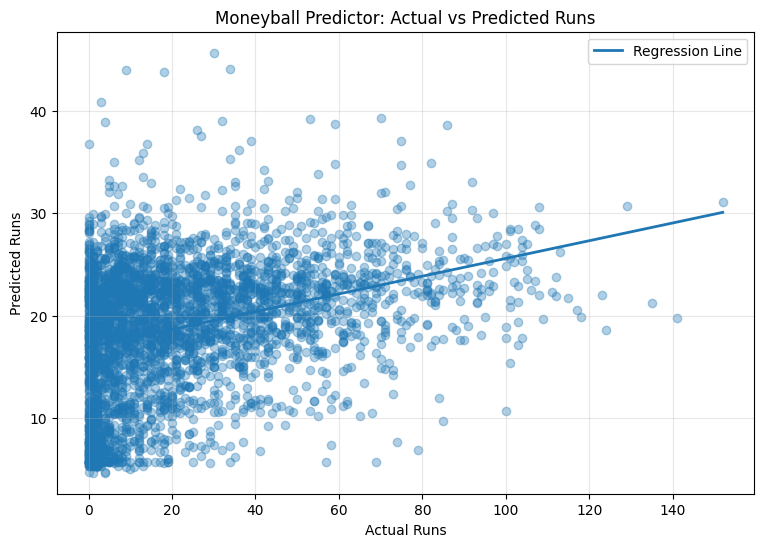

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    gb_pred,
    alpha=0.35
)

# Regression line
slope, intercept = np.polyfit(y_test, gb_pred, 1)
line_x = np.linspace(y_test.min(), y_test.max(), 100)
line_y = slope * line_x + intercept

plt.plot(
    line_x,
    line_y,
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Actual Runs")
plt.ylabel("Predicted Runs")
plt.title("Moneyball Predictor: Actual vs Predicted Runs")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#Show model performance

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, gb_pred)
rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
r2 = r2_score(y_test, gb_pred)

print("Moneyball Predictor Performance")
print("-" * 35)
print(f"MAE  : {mae:.2f} runs")
print(f"RMSE : {rmse:.2f} runs")
print(f"R²   : {r2:.3f}")

Moneyball Predictor Performance
-----------------------------------
MAE  : 16.72 runs
RMSE : 23.12 runs
R²   : 0.069


#Create a better player prediction function

In [ ]:
def predict_player_runs(player_name):

    player_data = player_match[
        player_match['batter'].str.lower() == player_name.lower()
    ].sort_values('date')

    if player_data.empty:
        print(f"Player '{player_name}' not found.")
        return

    latest = player_data.iloc[-1]

    X_player = latest[features].to_frame().T

    predicted_runs = gb_model.predict(X_player)[0]

    print(f"Player: {latest['batter']}")
    print(f"Last Match Runs: {latest['runs']:.0f}")
    print(f"Career Average: {latest['career_avg_runs']:.2f}")
    print(f"Recent 5-Match Average: {latest['last_5_avg_runs']:.2f}")
    print(f"Momentum: {latest['momentum']:.2f}")
    print(f"Estimated Next-Match Runs: {predicted_runs:.2f}")


# Example
predict_player_runs("V Kohli")

Player: V Kohli
Last Match Runs: 43
Career Average: 33.80
Recent 5-Match Average: 35.60
Momentum: 1.05
Estimated Next-Match Runs: 34.67


In [ ]:
from google.colab import files

matches_powerbi = matches.copy()

matches_powerbi.to_csv(
    "/content/matches_powerbi.csv",
    index=False
)

files.download("/content/matches_powerbi.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
deliveries_powerbi = deliveries.copy()

deliveries_powerbi.to_csv(
    "/content/deliveries_powerbi.csv",
    index=False
)

files.download("/content/deliveries_powerbi.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
player_match_powerbi = player_match.copy()

player_match_powerbi.to_csv(
    "/content/player_match_powerbi.csv",
    index=False
)

files.download("/content/player_match_powerbi.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
predictions_powerbi = prediction_table.copy()

predictions_powerbi.to_csv(
    "/content/player_predictions_powerbi.csv",
    index=False
)

files.download("/content/player_predictions_powerbi.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>